# Titanic Data Analysis

#### Here , We are performing EDA(Exploratory Data Analysis) on the dataset of Titanic Tragedy (15 April 1912) with the help of python libraries using numpy, pandas, matplotlib and seaborn libraries

* Objectives : 
-  Understand the dataset
-  Realizing survival patterns
-  Visualizing relationship between features


In [43]:
# importing libraries here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("images", exist_ok=True)


In [44]:
# Loading the dataset from the csv file

df = pd.read_csv("dataset/Titanic-Dataset.csv")
df
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Initial Data Inspection - Observations

- There are 891 rows X 12 columns.
- Age, Cabin, Embared cols has missing values.
- "Cabin" col has maximum missing value in the dataset.
- Target value is survived.
- Cols like "Age" and "Fare" have wide range of values.

In [45]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Missing Values Analysis : Observations

- Age col have missing values can be filled by median of age.
- Cabin has larger missing value that should be dropped .
- Embarked col missing values should be filled by mode.

In [46]:
df = df.drop("Cabin",axis=1)

In [47]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


C:\Users\Devansh\AppData\Local\Temp\ipykernel_43328\1413761131.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Devansh\AppData\Local\Temp\ipykernel_43328\1413761131.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

<Figure size 800x500 with 0 Axes>

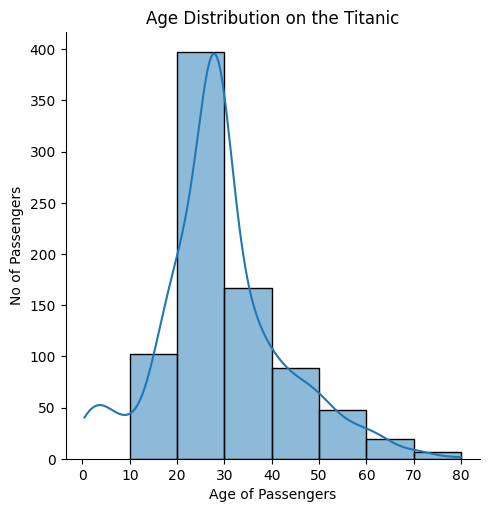

In [48]:
df["Age"]=pd.to_numeric(df['Age'],errors="coerce")
plt.figure(figsize=(8,5))
sns.displot(df["Age"],bins=[10,20,30,40,50,60,70,80],kde=True)
plt.title("Age Distribution on the Titanic")
plt.xlabel("Age of Passengers")
plt.ylabel("No of Passengers")
plt.savefig("images/Age_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- Many passengers on Titanic Ages between 20 to 40.
- The histogram plot is right skewed.
- Less number of passengers are there at extreme ends.

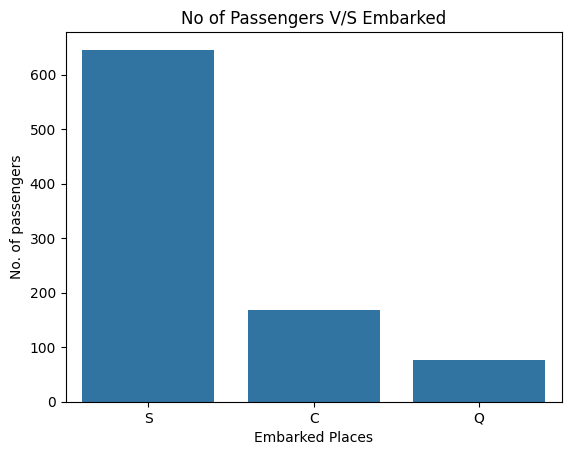

In [49]:
df["Embarked"]=df["Embarked"].astype("string")
sns.countplot(x="Embarked",data=df)
plt.title("No of Passengers V/S Embarked")
plt.xlabel("Embarked Places")
plt.ylabel("No. of passengers")
plt.savefig("images/Passengers_embarkation.png",dpi=300,bbox_inches="tight")
plt.show()


### Observations
- It is clearly seen that more than 600 passengers were from "Southampton".
- And From "Queenstown" were less than 100 passengers.
- Where "Cherbourg" had less than 200 and more than 150 were there.

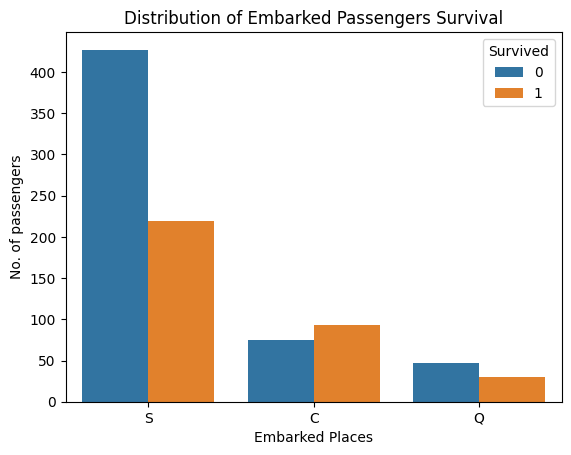

In [50]:
sns.countplot(x="Embarked",data=df,hue="Survived")
plt.title("Distribution of Embarked Passengers Survival")
plt.xlabel("Embarked Places")
plt.ylabel("No. of passengers")
plt.savefig("images/Survival_of_passengers_by_Embarkation.png",dpi=300,bbox_inches="tight")
plt.show()

### Observations
- Fewer than 250 out of more than 600 passengers from Southampton survived.
- More than half of the passengers from Cherbourg survived.
- Fewer than 50 passengers from Queenstown survived.

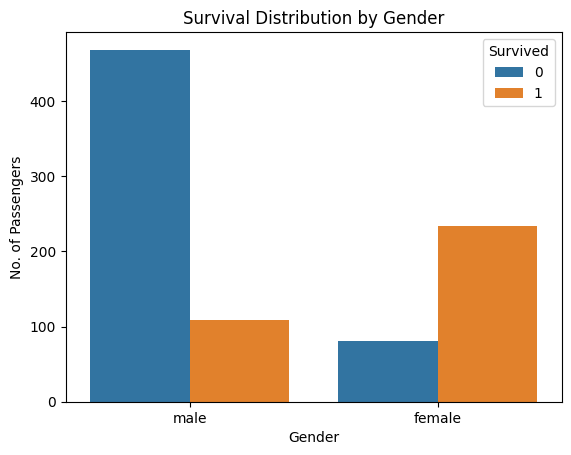

In [51]:
sns.countplot(x="Sex",data=df,hue="Survived")
plt.title("Survival Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("No. of Passengers")
plt.savefig("images/Survival_Distribution_by_Gender.png",dpi=300,bbox_inches="tight")
plt.show()

### Observations 
- From the graph it is clear that females had higher rate of survival compared to males.

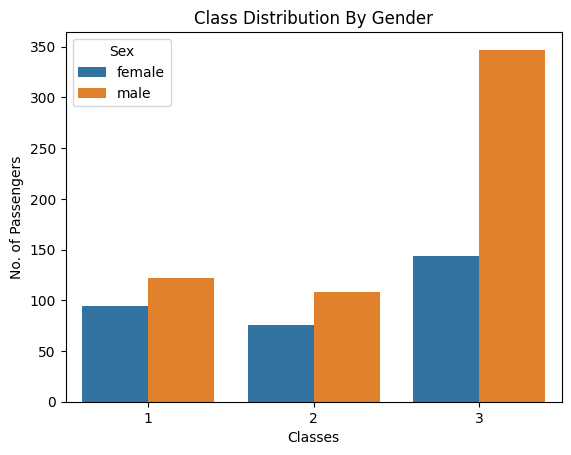

In [52]:
sns.countplot(x="Pclass",data=df,hue="Sex")
plt.title("Class Distribution By Gender")
plt.xlabel("Classes")
plt.ylabel("No. of Passengers")
plt.savefig("images/Class_Distribution_By_Gender.png",dpi=300,bbox_inches="tight")
plt.show()

### Observations
- The majority of passengers belonged to third class.
- Male passengers outnumbered female passengers across all classes.


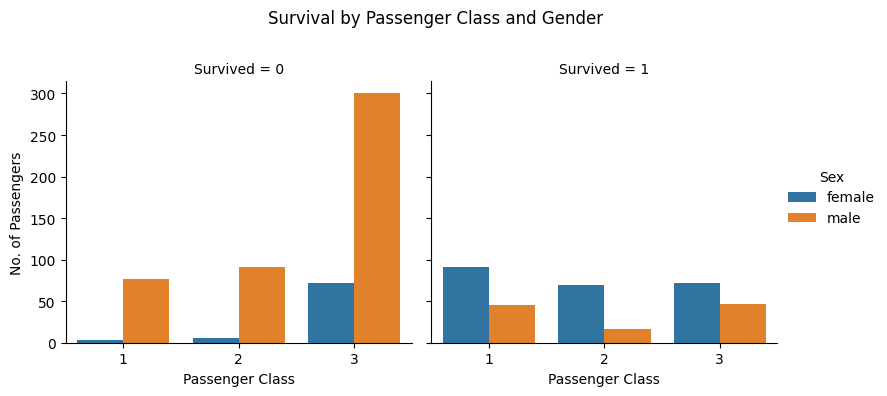

In [53]:
g=sns.catplot(
    x="Pclass",
    hue="Sex",
    col="Survived",
    data=df,
    kind="count",
    height=4,
    aspect=1
)

g.set_axis_labels("Passenger Class","No. of Passengers")

plt.subplots_adjust(top=0.8)
plt.suptitle("Survival by Passenger Class and Gender")
plt.savefig("images/Survival_by_Passenger_Class_and_Gender.png",dpi=300,bbox_inches="tight")
plt.show()


### Observations:
- Females had the higher rate than the males in sense of survival from each of the passenger class.
- Survival rate of 1st class was the highest among all 3 passenger classes.
- 3rd class males were the most who were not survived and dead.
- 1st class females had the highest survival rate among all classes in both genders.

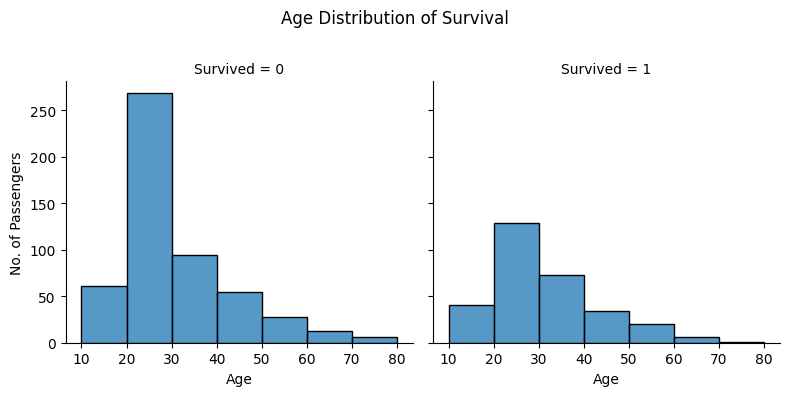

In [54]:
g2 = sns.displot(
    data=df,
    x="Age",
    bins=[10,20,30,40,50,60,70,80],
    col = "Survived",
    height=4,
    aspect=1,
)

g2.set_axis_labels("Age","No. of Passengers")

g2.fig.subplots_adjust(top=0.8)
g2.fig.suptitle("Age Distribution of Survival")
plt.savefig("images/Age_Distribution_of_Survival.png",dpi=300,bbox_inches="tight")
plt.show()

### Observations
- Passengers between 20 and 30 years of age had higher survival counts compared to other age groups.
- Non-survivors were spread across a wider age range, including more older passengers.


## Final Insights and Conclusion

- Gender was a strong factor influencing survival, with female passengers showing higher survival counts across all classes.
- Passenger class significantly impacted survival, with first-class passengers having the highest survival counts.
- Age also played a role in survival, with younger passengers showing higher survival counts compared to older age groups.
- Overall, survival on the Titanic was influenced by a combination of gender, passenger class, and age.
